## Standardize Imports and Initial Data Loading

### Subtask:
Consolidate all import statements, ensure the dataset is loaded once, and create a copy if needed for separate processing.


In [1]:
import joblib
import numpy as np
import tensorflow as tf
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay
import pydotplus
import collections
from IPython.display import Image
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from google.colab import files
import warnings
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from sklearn.linear_model import LogisticRegression

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [2]:
uploaded = files.upload()
df = pd.read_csv('mentalhealth.csv')


print("Dataset 'df' loaded successfully. First 5 rows:")
print(df.head())

Saving mentalhealth.csv to mentalhealth.csv
Dataset 'df' loaded successfully. First 5 rows:
  Unnamed: 0                                          statement   status
0          0                                         oh my gosh  Anxiety
1          1  trouble sleeping, confused mind, restless hear...  Anxiety
2          2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3          3  I've shifted my focus to something else but I'...  Anxiety
4          4  I'm restless and restless, it's been a month n...  Anxiety


## Drop Unnamed column and created copy of df




In [3]:
print("Columns in df after initial processing:", df.columns.tolist())
print("\nMissing values in df:")
print(df.isna().sum())

Columns in df after initial processing: ['Unnamed: 0', 'statement', 'status']

Missing values in df:
Unnamed: 0      3
statement     366
status         31
dtype: int64


In [4]:
df = df.drop(columns=['Unnamed: 0'])
print("Columns in df after dropping 'Unnamed: 0':", df.columns.tolist())
print("\nMissing values in df after dropping 'Unnamed: 0':")
print(df.isna().sum())

Columns in df after dropping 'Unnamed: 0': ['statement', 'status']

Missing values in df after dropping 'Unnamed: 0':
statement    366
status        31
dtype: int64


In [5]:
# df copy for EDA
df2 = df.copy()
print("\nDataFrame 'df2' created as a copy for EDA.")


DataFrame 'df2' created as a copy for EDA.


## Missing Value Imputation and Data Cleaning

### Subtask:
Implement the missing value imputation strategy for the 'status' and 'statement' columns, and then filter the dataset and label encode the 'status' column.


In [6]:
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Filter the df DataFrame to keep only rows where the 'status' is either 'Normal' or 'Depression'.
df = df[df['status'].isin(['Normal','Depression'])].copy() # Explicitly create a copy

# 2. Impute missing values in the 'status' column with its mode AFTER filtering
df['status'] = df['status'].fillna(df['status'].mode()[0])
print("Missing values after status filtering and imputation:")
print(df.isna().sum())

# 3. Prepare TF-IDF vectorizer for statement imputation
tfidf_imputer = TfidfVectorizer()
df_non_null_statements = df.dropna(subset=['statement'])
tfidf_matrix_imputer = tfidf_imputer.fit_transform(df_non_null_statements['statement'].astype(str))

# 4. Define the imputation function for 'statement'
def impute_missing_statement(row):
    if pd.isnull(row['statement']):
        # Filter statements from df_non_null_statements that match the current row's status
        status_mask = df_non_null_statements['status'] == row['status']

        # If no statements exist for the current status (e.g., if the status itself was imputed and no original statement matches)
        # Fallback to the most frequent statement if no status-specific match is found
        if status_mask.sum() == 0:
            return df_non_null_statements['statement'].mode()[0]

        # Transform the current row's status to TF-IDF (even if it's just a word)
        # Using a dummy vector for cosine_similarity if the actual statement is missing
        current_status_tfidf = tfidf_imputer.transform([str(row['status'])])

        # Get TF-IDF vectors for statements with the matching status
        matching_statements_tfidf = tfidf_matrix_imputer[status_mask.values]

        # Compute cosine similarity between the current status vector and matching statement vectors
        similarity_scores = cosine_similarity(current_status_tfidf, matching_statements_tfidf)

        # Get the index of the best match within the filtered df_non_null_statements
        best_match_idx_in_filtered = np.argmax(similarity_scores)

        # Get the actual index in the original df_non_null_statements DataFrame
        original_idx_of_best_match = df_non_null_statements.loc[status_mask.index[best_match_idx_in_filtered], 'statement']

        return original_idx_of_best_match
    return row['statement']

# 5. Apply the imputation function to the 'statement' column
df['statement'] = df.apply(impute_missing_statement, axis=1)

# 6. Verify no remaining missing values
print("\nMissing values after statement imputation:")
print(df.isna().sum())

# 7. Initialize a LabelEncoder and apply it to the 'status' column of df.
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

# 8. Print the value counts of the 'status' column after label encoding.
print("\nValue counts of 'status' after filtering and label encoding:")
print(df['status'].value_counts())

Missing values after status filtering and imputation:
statement    8
status       0
dtype: int64

Missing values after statement imputation:
statement    0
status       0
dtype: int64

Value counts of 'status' after filtering and label encoding:
status
1    16348
0    15399
Name: count, dtype: int64


## Advanced Text Preprocessing

**Reasoning**: Implementing advanced text preprocessing steps like lemmatization, comprehensive punctuation/number/special character removal, and filtering short words will enhance the quality of the text data. This will help the models better understand the semantic content of the statements by reducing noise and standardizing word forms, potentially leading to improved classification performance.

In [7]:
# Download necessary NLTK data if not already present
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
# Add the missing download for 'punkt_tab'
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation, numbers, and special characters (keep apostrophes for contractions)
    text = re.sub(r'[^a-zA-Z\s\[\]]', '', text)
    # Tokenize words
    words = word_tokenize(text)
    # Remove short words (length < 2) and lemmatize
    processed_words = [lemmatizer.lemmatize(word) for word in words if len(word) > 1]
    return ' '.join(processed_words)

# Apply preprocessing to the 'statement' column
df['statement'] = df['statement'].apply(preprocess_text)

print("Text preprocessing complete. Sample of preprocessed statements:")
print(df['statement'].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Text preprocessing complete. Sample of preprocessed statements:
733         gr gr dreaming of ex crush to be my game god
734                                     wkwkwk what joke
735    leaf are also standby in front of the pc becau...
736           thank god even though it just ride through
737    wedding teaser concept using the song day only...
Name: statement, dtype: object


## Word Frequency Analysis for Depression and Normal Statuses




In [8]:
def analyze_word_frequency(status_type, dataframe):
    """
    Analyzes and visualizes the top 20 most frequent words for a given mental health status.

    Args:
        status_type (str): The mental health status to analyze (e.g., 'normal', 'depression').
        dataframe (pd.DataFrame): The DataFrame containing 'statement' and 'status' columns.
    """

    # Ensure 'status' column is lowercase for consistent filtering
    dataframe['status'] = dataframe['status'].str.lower()

    # Filter statements for the desired status
    filtered_statements = dataframe[dataframe['status'] == status_type.lower()]['statement']

    # Combine all statements into a single string, handling NaN values
    all_statements = ' '.join(str(x) for x in filtered_statements.dropna())

    # Tokenize the statements and count word frequencies
    words = re.findall(r"\b[a-zA-Z']+\b", all_statements.lower())
    word_counts = Counter(words)

    # Define stopwords (include both NLTK's STOPWORDS and custom ones)
    stopwords = set(STOPWORDS)
    custom_stopwords = {
        'every', 'take', 'last', 'day', 'days', 'anything', 'see', 'right', 'way', 'ago', 'said',
        'im', 'ive', 'its', 'don', 'getting', 'm', 't', 's', 've', 'went', 'now', 'go', 'back',
        'got', 'anyone', 'started', 'want', 'will', 'it.', 'it', 'but', 'in', 'a', 'for', 'of',
        'and', 'to', 'have', 'with', 'or', 'this', 'like', 'about', 'on', 'so', 'just', 'i',
        'my', 'is', 'the', 'do', 'has', 'so', 'just', 'have', 'in', 'all', 'it', 'can', 'on',
        'that', 'for', 'this', 'to', 'had', 'my', 'i', 'and', 'with', 'be', 'from', 'not', 'at',
        'like', 'know', "i'm", 'feel', 'as', 'was', 'up', 'me', 'of', 'you', 'a', 'is', 'but',
        'the', 'or', 'am', 'if', 'really', 'because', 'when', 'out', 'about', 'get', 'going',
        'things', 'even', 'time', 'still', 'much', 'one', 'would', 'think', 'more', 'something',
        'also', 'felt', 'lot', 'first','around', 'make', 'sure', 'feels', 'little', 'two', 'side',
        'feeling', 'well', 'oh', 'need', 'come', 'yes', 'oh', 'wa', 'though', 'say','thing'
    }
    stopwords.update(custom_stopwords)

    # Remove stopwords
    filtered_word_counts = {word: count for word, count in word_counts.items() if word not in stopwords}

    # Get the top 20 most frequent words
    most_common_words = dict(Counter(filtered_word_counts).most_common(20))

    # Create a table visualizing results
    word_freq_df = pd.DataFrame(most_common_words.items(), columns=['Word', 'Frequency'])
    word_freq_df.index = range(1, len(word_freq_df) + 1)
    print(f"\nTop 20 Most Frequent Words Associated with {status_type.title()} Status\n")
    print(word_freq_df)

    # Create a bar chart
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(most_common_words.keys()), y=list(most_common_words.values()), palette='viridis', hue=list(most_common_words.keys()), legend=False)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Most Frequent Words Associated with {status_type.title()} Status')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Top 20 Most Frequent Words Associated with Normal Status

       Word  Frequency
1      good        679
2    people        621
3      work        587
4     today        449
5      love        413
6      help        377
7   morning        373
8      life        319
9      home        317
10      new        316
11    never        315
12    sleep        311
13    night        295
14     long        291
15    years        289
16   always        262
17  someone        259
18     year        252
19      bad        244
20   please        243


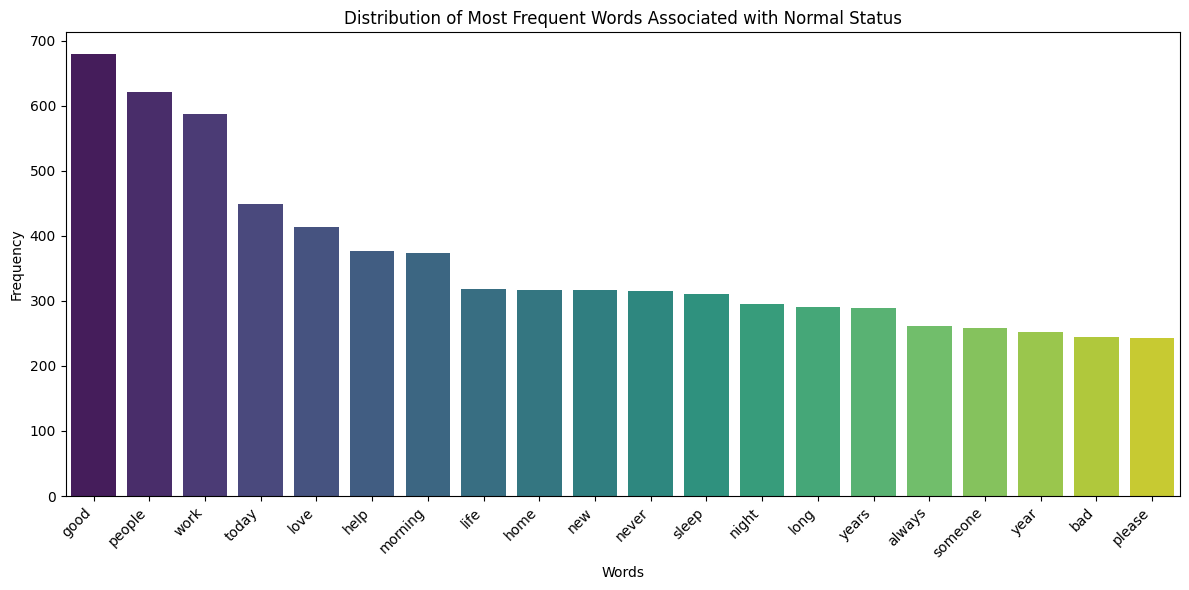


Top 20 Most Frequent Words Associated with Depression Status

          Word  Frequency
1         life      11307
2       people       7912
3   depression       6546
4        never       5474
5         help       4891
6      anymore       4245
7         work       4154
8      friends       4120
9       always       4064
10  everything       3981
11      better       3933
12       years       3894
13        good       3814
14        year       3736
15     nothing       3656
16        hate       3488
17     someone       3428
18     anxiety       3365
19      family       3307
20         bad       3235


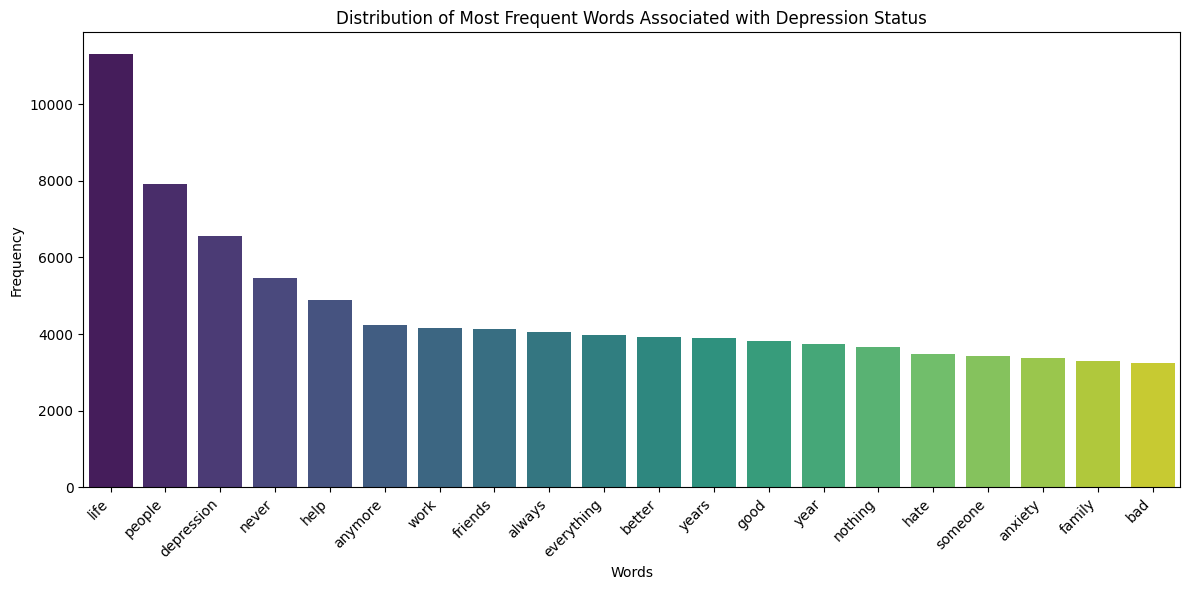

In [9]:
mental_health_statuses = [
    'Normal', 'Depression'
]

# Call the function for each status
for status in mental_health_statuses:
    analyze_word_frequency(status, df2.copy()) # Use a copy of df2 to avoid permanent lowercase conversion affecting subsequent calls if df2 were modified in place

## TF-IDF Feature Extraction



In [10]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency

# Note: TF-IDF fitting and transformation will now happen after data splitting to prevent data leakage.
# The vectorizer itself is initialized here and saved.

print("TF-IDF vectorizer initialized. Fitting will occur after data split.")

# Save the TF-IDF vectorizer for future use (e.g., transforming new statements)
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'")

TF-IDF vectorizer initialized. Fitting will occur after data split.
TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'


## Data Splitting




In [11]:
from sklearn.model_selection import train_test_split

# Set X to the raw statements and y to df['status']
X = df['statement']
y = df['status']

# Split the dataset into training and testing sets with stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit the TF-IDF vectorizer on the training data (raw text) and transform both train and test sets
X_train = tfidf_vectorizer.fit_transform(X_train_raw)
X_test = tfidf_vectorizer.transform(X_test_raw)

print(f"Shape of X_train (TF-IDF features): {X_train.shape}")
print(f"Shape of X_test (TF-IDF features): {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train (TF-IDF features): (25397, 5000)
Shape of X_test (TF-IDF features): (6350, 5000)
Shape of y_train: (25397,)
Shape of y_test: (6350,)


## Implement Stratified K-Fold for GridSearchCV




In [12]:
# Define the parameter grid for GridSearchCV
param_grid_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV with StratifiedKFold
grid_search_log_reg_stratified = GridSearchCV(estimator=LogisticRegression(random_state=42, solver='liblinear'),
                                 param_grid=param_grid_log_reg,
                                 cv=skf, # Use StratifiedKFold
                                 scoring='accuracy',
                                 n_jobs=-1,
                                 verbose=1)

# Fit GridSearchCV to the training data
grid_search_log_reg_stratified.fit(X_train, y_train)

# Get the best estimator
best_log_reg_model_stratified = grid_search_log_reg_stratified.best_estimator_

# Make predictions on the test set
y_pred_log_reg_stratified = best_log_reg_model_stratified.predict(X_test)

# Calculate accuracy
accuracy_log_reg_stratified = accuracy_score(y_test, y_pred_log_reg_stratified)
print(f"\nLogistic Regression Model Accuracy with Stratified K-Fold: {accuracy_log_reg_stratified:.4f}")

# Print the best parameters found by GridSearchCV
print("Best parameters for Logistic Regression with Stratified K-Fold:", grid_search_log_reg_stratified.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Logistic Regression Model Accuracy with Stratified K-Fold: 0.9589
Best parameters for Logistic Regression with Stratified K-Fold: {'C': 10, 'penalty': 'l2'}


In [13]:
# Define the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize StratifiedKFold (re-use the instance created for Logistic Regression if still in scope, otherwise re-initialize)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV with StratifiedKFold
grid_search_dt_stratified = GridSearchCV(estimator=dt_classifier,
                                         param_grid=param_grid,
                                         cv=skf, # Use StratifiedKFold
                                         scoring='accuracy',
                                         n_jobs=-1,
                                         verbose=1)

# Fit GridSearchCV to the training data
grid_search_dt_stratified.fit(X_train, y_train)

# Get the best estimator
best_dt_model_stratified = grid_search_dt_stratified.best_estimator_

# Make predictions on the test set
y_pred_dt_stratified = best_dt_model_stratified.predict(X_test)

# Calculate accuracy
accuracy_dt_stratified = accuracy_score(y_test, y_pred_dt_stratified)
print(f"\nDecision Tree Model Accuracy with Stratified K-Fold: {accuracy_dt_stratified:.4f}")

# Print the best parameters found by GridSearchCV
print("Best parameters for Decision Tree with Stratified K-Fold:", grid_search_dt_stratified.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits

Decision Tree Model Accuracy with Stratified K-Fold: 0.9222
Best parameters for Decision Tree with Stratified K-Fold: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10}


## Train Neural Network Model



In [14]:
print("Re-training Neural Network model from scratch...")
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train.toarray(), y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Evaluate the model on the test set
loss_retrained_nn_new, accuracy_retrained_nn_new = model.evaluate(X_test.toarray(), y_test, verbose=0)
print(f"\nRe-trained Neural Network Model Accuracy (new features): {accuracy_retrained_nn_new:.4f}")

Re-training Neural Network model from scratch...
Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8812 - loss: 1.1322 - val_accuracy: 0.9470 - val_loss: 0.3148
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9430 - loss: 0.3156 - val_accuracy: 0.9476 - val_loss: 0.2774
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9447 - loss: 0.2960 - val_accuracy: 0.9459 - val_loss: 0.2788
Epoch 4/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9475 - loss: 0.2818 - val_accuracy: 0.9482 - val_loss: 0.2641
Epoch 5/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9492 - loss: 0.2692 - val_accuracy: 0.9484 - val_loss: 0.2580
Epoch 6/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9485 - loss: 0.2662 - val_accuracy: 0.9500 - val_loss: 0.2575
Epoch 7/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9495 - loss: 0.2612 - val_accuracy: 0.9504 - val_loss: 0.2514
Epoch 8/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2

## Training vs. Validation Accuracy and Loss for Neural Network

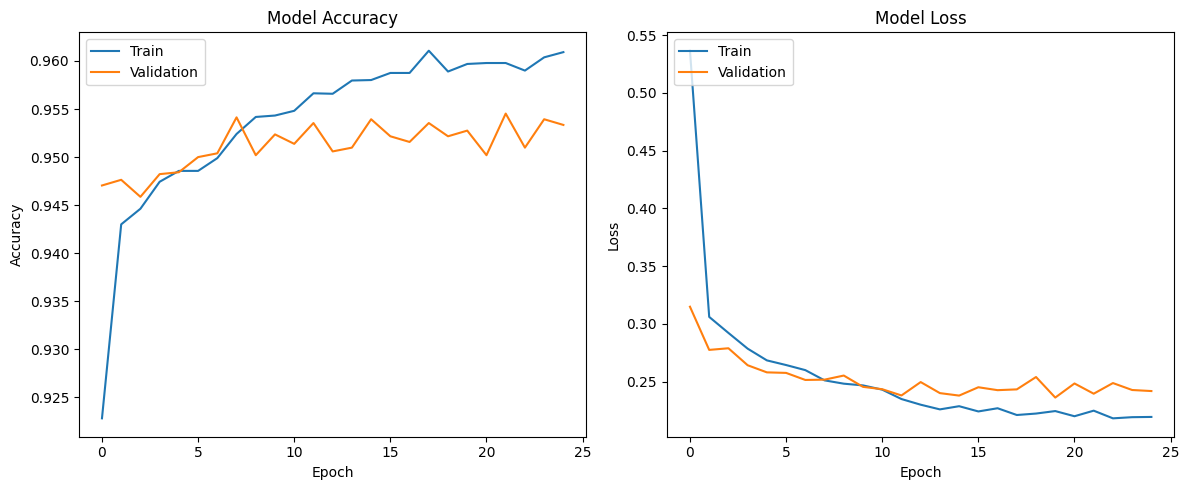

In [15]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## Compare Model Accuracies

### Subtask:
Create a new section to compile and display the accuracies of all three models (Logistic Regression, Decision Tree, and ANN) in a comparative table for clear analysis.

In [16]:
model_accuracies = {
    'Logistic Regression': accuracy_log_reg_stratified,
    'Decision Tree': accuracy_dt_stratified,
    'Neural Network': accuracy_retrained_nn_new
}

accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\nComparative Model Accuracies:")
print(accuracy_df)


Comparative Model Accuracies:
                 Model  Accuracy
0  Logistic Regression  0.958898
1       Neural Network  0.957323
2        Decision Tree  0.922205


## Confusion Matrices

<Figure size 600x600 with 0 Axes>

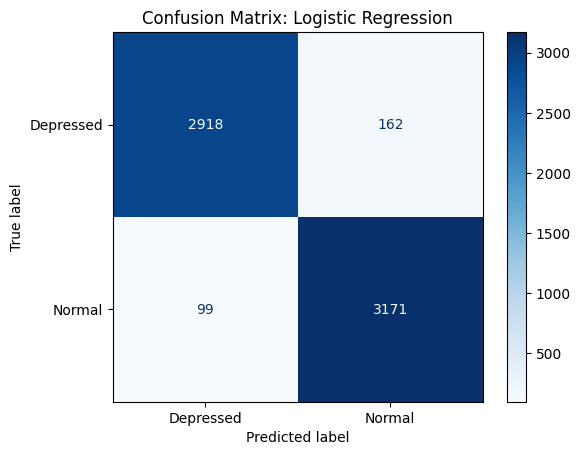

In [17]:
# Confusion Matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg_stratified)
display_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['Depressed', 'Normal'])

plt.figure(figsize=(6, 6))
display_log_reg.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

<Figure size 600x600 with 0 Axes>

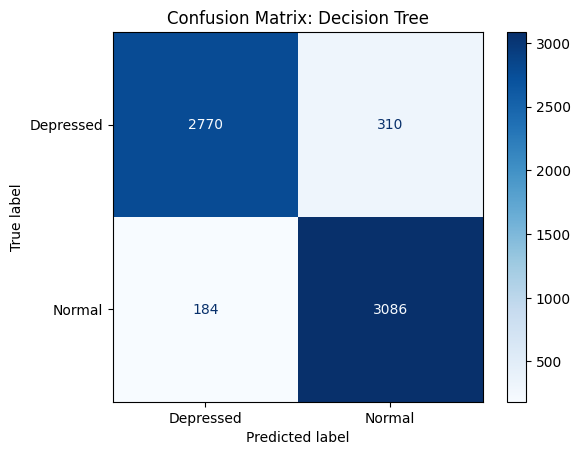

In [18]:
# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt_stratified)
display_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Depressed', 'Normal'])

plt.figure(figsize=(6, 6))
display_dt.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Decision Tree')
plt.show()

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


<Figure size 600x600 with 0 Axes>

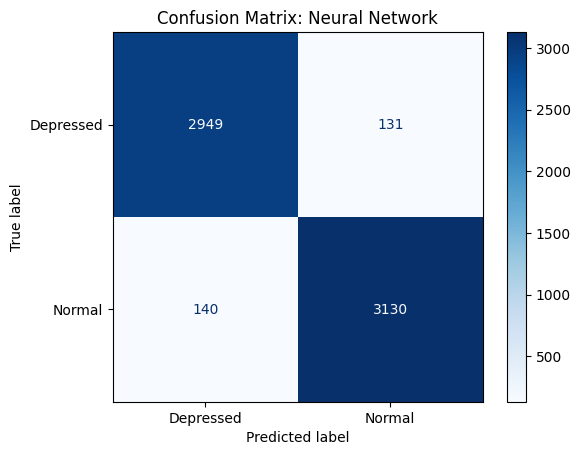

In [19]:
# Confusion Matrix for Neural Network
nn_test_predictions = (model.predict(X_test.toarray()).flatten() > 0.5).astype(int)
cm_nn = confusion_matrix(y_test, nn_test_predictions)
display_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Depressed', 'Normal'])

plt.figure(figsize=(6, 6))
display_nn.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Neural Network')
plt.show()

## F1 Scores

In [20]:
from sklearn.metrics import f1_score

f1_log_reg_stratified = f1_score(y_test, y_pred_log_reg_stratified)
print(f"Logistic Regression Model F1 Score with Stratified K-Fold: {f1_log_reg_stratified:.4f}")

Logistic Regression Model F1 Score with Stratified K-Fold: 0.9605


In [21]:
from sklearn.metrics import f1_score

f1_dt_stratified = f1_score(y_test, y_pred_dt_stratified)
print(f"Decision Tree Model F1 Score with Stratified K-Fold: {f1_dt_stratified:.4f}")

Decision Tree Model F1 Score with Stratified K-Fold: 0.9259


In [22]:
from sklearn.metrics import f1_score

nn_test_predictions = (model.predict(X_test.toarray()).flatten() > 0.5).astype(int)
f1_retrained_nn_new = f1_score(y_test, nn_test_predictions)
print(f"Re-trained Neural Network Model F1 Score: {f1_retrained_nn_new:.4f}")

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Re-trained Neural Network Model F1 Score: 0.9585


## Plot Precision-Recall Curve for Logistic Regression

### Subtask:
Add a new code cell to calculate and plot the Precision-Recall curve for the re-trained Logistic Regression model. This will provide a deeper insight into the model's performance in terms of precision vs. recall trade-offs.


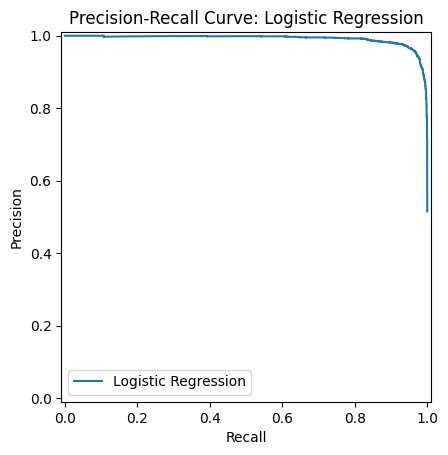

In [23]:
# 1. Get the probability predictions for the positive class (class 1) on the test set
y_scores_log_reg = best_log_reg_model_stratified.predict_proba(X_test)[:, 1]

# 2. Calculate the precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test, y_scores_log_reg)

# 3. Create and plot a PrecisionRecallDisplay object
display = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='Logistic Regression')
display.plot()
plt.title('Precision-Recall Curve: Logistic Regression')
plt.show()

## Plot Precision-Recall Curve for Decision Tree




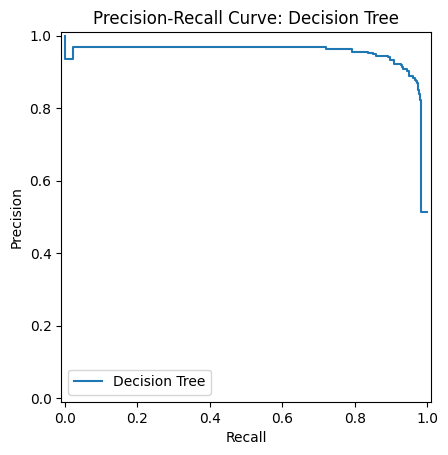

In [24]:
# 1. Get the probability predictions for the positive class (class 1) on the test set
y_scores_dt = best_dt_model_stratified.predict_proba(X_test)[:, 1]

# 2. Calculate the precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test, y_scores_dt)

# 3. Create and plot a PrecisionRecallDisplay object
display = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='Decision Tree')
display.plot()
plt.title('Precision-Recall Curve: Decision Tree')
plt.show()

## Plot Precision-Recall Curve for Neural Network


199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


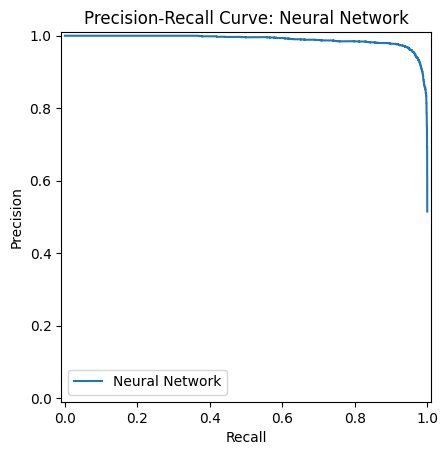

In [25]:
# 1. Get the probability predictions for the positive class (class 1) on the test set
y_scores_nn = model.predict(X_test.toarray()).flatten()

# 2. Calculate the precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test, y_scores_nn)

# 3. Create and plot a PrecisionRecallDisplay object
display = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='Neural Network')
display.plot()
plt.title('Precision-Recall Curve: Neural Network')
plt.show()

## Refined New Statement Testing and Output

This section provides a more concise and informative analysis of the model predictions for new statements. For each statement, predictions and confidence levels from both the Decision Tree and Neural Network models are presented side-by-side, followed by a comparative interpretation.

In [26]:
new_statements = [
    "I can't stop worrying about everything",
    "I've been working hard, and seeing the results makes me feel incredibly happy and fulfilled",
    "Even the smallest things feel like too much right now",
    "I can't stop smiling",
    "Today has been amazing!"
]

# Convert the new statements to TF-IDF features
new_statements_tfidf = tfidf_vectorizer.transform(new_statements)  # Use the same TF-IDF vectorizer

# Predictions using Decision Tree (including probabilities)
dt_probabilities = best_dt_model_stratified.predict_proba(new_statements_tfidf)[:, 1]  # Probability of "Normal"
dt_predictions = (dt_probabilities > 0.5).astype(int)  # Convert probabilities to binary labels

# Predictions using ANN Model (Neural Network)
nn_probabilities = model.predict(new_statements_tfidf.toarray()).flatten()  # Get probabilities for "Normal"
nn_predictions = (nn_probabilities > 0.5).astype(int)  # Convert probabilities to binary labels

# Predictions using Logistic Regression Model
log_reg_probabilities = best_log_reg_model_stratified.predict_proba(new_statements_tfidf)[:, 1] # Probability of "Normal"
log_reg_predictions = (log_reg_probabilities > 0.5).astype(int) # Convert probabilities to binary labels

# Output results in a more concise format for easy comparison
print("Classification Results for New Statements:")
print("-------------------------------------------")
for i, statement in enumerate(new_statements):
    dt_confidence = dt_probabilities[i]
    nn_confidence = nn_probabilities[i]
    log_reg_confidence = log_reg_probabilities[i]

    dt_status = 'Normal' if dt_predictions[i] == 1 else 'Depressed'
    nn_status = 'Normal' if nn_predictions[i] == 1 else 'Depressed'
    log_reg_status = 'Normal' if log_reg_predictions[i] == 1 else 'Depressed'

    print(f"\nStatement: '{statement}'")
    print(f"  Decision Tree: {dt_status} (Normal Prob: {dt_confidence:.2f}, Depressed Prob: {1 - dt_confidence:.2f})")
    print(f"  Neural Network: {nn_status} (Normal Prob: {nn_confidence:.2f}, Depressed Prob: {1 - nn_confidence:.2f})")
    print(f"  Logistic Regression: {log_reg_status} (Normal Prob: {log_reg_confidence:.2f}, Depressed Prob: {1 - log_reg_confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Classification Results for New Statements:
-------------------------------------------

Statement: 'I can't stop worrying about everything'
  Decision Tree: Normal (Normal Prob: 0.97, Depressed Prob: 0.03)
  Neural Network: Normal (Normal Prob: 0.86, Depressed Prob: 0.14)
  Logistic Regression: Normal (Normal Prob: 0.77, Depressed Prob: 0.23)

Statement: 'I've been working hard, and seeing the results makes me feel incredibly happy and fulfilled'
  Decision Tree: Depressed (Normal Prob: 0.35, Depressed Prob: 0.65)
  Neural Network: Depressed (Normal Prob: 0.12, Depressed Prob: 0.88)
  Logistic Regression: Depressed (Normal Prob: 0.48, Depressed Prob: 0.52)

Statement: 'Even the smallest things feel like too much right now'
  Decision Tree: Normal (Normal Prob: 0.83, Depressed Prob: 0.17)
  Neural Network: Normal (Normal Prob: 0.98, Depressed Prob: 0.02)
  Logistic Regression: Normal (Normal Prob: 0.85, Depressed Prob: 0.15)

Statement: 'I can't sto

In [27]:
# Save Decision Tree Model
joblib.dump(best_dt_model_stratified, "decision_tree_model.pkl")
print("Decision Tree model saved as 'decision_tree_model.pkl'")

# Save Neural Network Model
model.save("ann_model.keras") # Changed to .keras format
print("Neural Network model saved as 'ann_model.keras'")

#Save Logistic Regression Model
joblib.dump(best_log_reg_model_stratified, "logistic_regression_model.pkl")
print("Logistic Regression model saved as 'logistic_regression_model.pkl'")

Decision Tree model saved as 'decision_tree_model.pkl'
Neural Network model saved as 'ann_model.keras'
Logistic Regression model saved as 'logistic_regression_model.pkl'
